In [1]:
import json, numpy as np, time, random
from sklearn import svm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_ind

RANDOM_SEED = 15
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [2]:
#[("side tube", 2, 3), ("glass tube", 0, 3), ("metal surface", 2, 5), ("adult form", 4, 4),]
with open("all_features_newsurps.json", "r") as f:
    all_features = json.load(f)
with open("coha/all_features_coha.json", "r") as f:
    all_features_coha = json.load(f)
print(all_features["side tube"].keys())

dict_keys(['abs_freq_bin1', 'abs_freq_bin2', 'abs_freq_bin3', 'abs_freq_bin4', 'abs_freq_bin5', 'abs_freq_bin6', 'abs_para_freq_bin1', 'abs_para_freq_bin2', 'abs_para_freq_bin3', 'abs_para_freq_bin4', 'abs_para_freq_bin5', 'abs_para_freq_bin6', 'years', 'topics', 'head_freq_bin1', 'mod_freq_bin1', 'freq_bin1', 'para_freq_bin1', 'head_freq_bin2', 'mod_freq_bin2', 'freq_bin2', 'para_freq_bin2', 'head_freq_bin3', 'mod_freq_bin3', 'freq_bin3', 'para_freq_bin3', 'head_freq_bin4', 'mod_freq_bin4', 'freq_bin4', 'para_freq_bin4', 'head_freq_bin5', 'mod_freq_bin5', 'freq_bin5', 'para_freq_bin5', 'head_freq_bin6', 'mod_freq_bin6', 'freq_bin6', 'para_freq_bin6', 'temp_divergence', 'topic_divergence', 'avg_surprisal_bin1', 'avg_surprisal_bin2', 'avg_surprisal_bin3', 'avg_surprisal_bin4', 'avg_surprisal_bin5', 'avg_surprisal_bin6', 'cosine_mod_bin1', 'cosine_head_bin1', 'cosine_mod_bin2', 'cosine_head_bin2', 'cosine_mod_bin3', 'cosine_head_bin3', 'cosine_mod_bin4', 'cosine_head_bin4', 'cosine_mod_b

### Settings: Set desired corpus and constituent classification task here

In [3]:
mod0_head1 = 0
constituent = ["modifier", "head"][mod0_head1]
features_used = all_features
n_top_and_bottom = 60 

In [4]:
def get_bad_annotators():
    bad_ids = []
    for batch in range(8):
        
        with open(f"annotations/form_urs_{batch}_results_judgements.csv") as f:
            annotator_judgements = {}
            for line in f.readlines()[1:]:
                _, _, anno_id, judgement = line.strip().split(',')
                if anno_id not in annotator_judgements:
                    annotator_judgements[anno_id] = [judgement]
                annotator_judgements[anno_id].append(judgement)
        for anno_id, judgements in annotator_judgements.items():
            if all([j == '5' for j in judgements]):
                bad_ids.append(anno_id)
    #print("excluding annotators: ", bad_ids)
    return list(set(bad_ids))

In [5]:
def get_all_judgements(all_features=all_features, measure="avg"):
    mod_judgements = {compound: [] for compound in all_features.keys()}
    head_judgements = {compound: [] for compound in all_features.keys()}
    control_items = ["elbow grease", "sex bomb", "lime tree", "mental disorder", "milk tooth", "silver lining", "nut case", "insurance company"]
    excluded_annotators = get_bad_annotators()

    for batch in range(8):
        with open(f"annotations/form_urs_{batch}_results_judgements.csv") as f:
            for line in f.readlines()[1:]:
                compound, constituent, anno_id, judgement = line.strip().split(',')
                if compound not in mod_judgements:
                    continue #only CCOHA
                if compound in control_items or anno_id in excluded_annotators:
                    continue
                mod, head = compound.split()
                if constituent == mod:
                    mod_judgements[compound].append(int(judgement))
                elif constituent == head:
                    head_judgements[compound].append(int(judgement))
                else:
                    raise Exception("Unclear constituent")
    if measure == "avg":
        return [(compound, np.average(mod_judgements[compound]), np.average(head_judgements[compound])) for compound in all_features.keys() if mod_judgements[compound]]
    elif measure == "median":
        return [(compound, np.median(mod_judgements[compound]), np.median(head_judgements[compound])) for compound in all_features.keys() if mod_judgements[compound]]
    else:
        raise Exception("unknown measure")
annotated_compounds = get_all_judgements(features_used)

#print(annotated_compounds)
print(len(annotated_compounds))

annotated_compounds.sort(key=lambda x:x[mod0_head1+1]) # sort by annotation score for either head or mod
print("lowest low ", annotated_compounds[0])
print("highest low ", annotated_compounds[n_top_and_bottom])
print("lowest high ", annotated_compounds[-n_top_and_bottom])
print("highest high ", annotated_compounds[-1])

target_compounds = annotated_compounds[:n_top_and_bottom] + annotated_compounds[-n_top_and_bottom:]
targets = [0] * n_top_and_bottom + [1] * n_top_and_bottom

200
lowest low  ('penny weight', 1.4666666666666666, 4.066666666666666)
highest low  ('yield point', 3.3076923076923075, 3.0)
lowest high  ('chloride solution', 4.153846153846154, 3.5384615384615383)
highest high  ('day time', 4.785714285714286, 4.0)


Aggregation of cosines over all 3 Word2Vec models - only necessary if not already the case in all_features

In [6]:
if "cosine2_mod_bin6" in all_features["salt water"]:
    with open("all_features.json", "r") as f:
        all_features = json.load(f)
    with open("coha/all_features_coha.json", "r") as f:
        all_features_coha = json.load(f)
    print(all_features["salt water"][f"cosine_mod_bin6"], all_features["salt water"][f"cosine2_mod_bin6"], all_features["salt water"][f"cosine3_mod_bin6"])
    for compound, features in all_features.items():
        for bin in range(1, 7):
            features[f"cosine_mod_bin{bin}"] = (features[f"cosine_mod_bin{bin}"] +\
                                                features[f"cosine2_mod_bin{bin}"] + \
                                                    features[f"cosine3_mod_bin{bin}"])/3
            features[f"cosine_head_bin{bin}"] = (features[f"cosine_head_bin{bin}"] +\
                                                features[f"cosine2_head_bin{bin}"] + \
                                                    features[f"cosine3_head_bin{bin}"])/3
    print(all_features["salt water"][f"cosine_mod_bin6"])
    print(all_features_coha["salt water"][f"cosine_mod_bin6"], all_features_coha["salt water"][f"cosine2_mod_bin6"], all_features_coha["salt water"][f"cosine3_mod_bin6"])
    for compound, features in all_features_coha.items():
        for bin in range(3, 7):
            features[f"cosine_mod_bin{bin}"] = (features[f"cosine_mod_bin{bin}"] +\
                                                features[f"cosine2_mod_bin{bin}"] + \
                                                    features[f"cosine3_mod_bin{bin}"])/3
            features[f"cosine_head_bin{bin}"] = (features[f"cosine_head_bin{bin}"] +\
                                                features[f"cosine2_head_bin{bin}"] + \
                                                    features[f"cosine3_head_bin{bin}"])/3
    print(all_features_coha["salt water"][f"cosine_mod_bin6"])

0.6321806907653809 0.6247690320014954 0.6337493062019348
0.6302330096562704
0.7406785488128662 0.7642936706542969 0.7551671266555786
0.7533797820409139


### Feature selection: Set any features that you want included to "True"

In [17]:
feature_set = list(all_features["side tube"].keys())

include_features = {
    # "cosine_mod_bin6": False,
    # "freq_bin6": False,
    # "avg_mod_surprisal_bin6": False,
    # "avg_head_surprisal_bin6": False,
    "cosine_mod": False,
    "cosine_head": False,
    # "cosine2_mod": False,
    # "cosine2_head": False,
    # "cosine3_mod": False,
    # "cosine3_head": False,
    "freq": False,
    "mod_freq": False,
    "head_freq": False,
    "para_freq": False,
    "avg_mod_surprisal": False,
    "avg_head_surprisal": False,
    "temp_div": True,
    "topic_div": False,
    "neighborhood": False
}

included = [prefix for prefix, incl in include_features.items() if incl]

features = []
feature_names = [feat_name for feat_prefix in included for feat_name in all_features["salt water"].keys() if feat_name.startswith(feat_prefix)]
print(feature_names)
for compound in target_compounds:
    compound_features = []
    for feat_prefix in included:
        compound_features.extend([value for feat_name, value in all_features[compound[0]].items() if feat_name.startswith(feat_prefix)])
    features.append(compound_features)
included_coha = [] #so you don't get an exception if next cells aren't run 
included_synchronic = []

['temp_divergence']


In [8]:
# CCOHA features
include_features_coha = {
    "cosine_mod": False,
    "cosine_head": False,
    # "cosine2_mod": False,
    # "cosine2_head": False,
    # "cosine3_mod": False,
    # "cosine3_head": False,
    "freq": False,
    "mod_freq": False,
    "head_freq": False,
    "para_freq": False,
    "avg_mod_surprisal": False,
    "avg_head_surprisal": False,
    "temp_div": False,
    "topic_div": False,
    "neighborhood": False
}
included_coha = [prefix for prefix, incl in include_features_coha.items() if incl]

for i, compound in enumerate(target_compounds):
    if compound[0] in all_features_coha:
        coha_features = []
        for feat_prefix in included_coha:
            coha_features.extend([value for feat_name, value in all_features_coha[compound[0]].items() if feat_name.startswith(feat_prefix)])
            feature_names.extend(["coha_" + feat_name for feat_name in all_features_coha[compound[0]].keys() if feat_name.startswith(feat_prefix)])
        features[i].extend(coha_features)
    else:
        features[i].extend([0]*(len(features[0])-len(features[i]))) #TODO unsafe: breaks if first compound not in coha

In [45]:
include_features_synchronic = {
"abs_freq": False,
"cosine_head": False,
"cosine_mod": False,
"abs_mod_freq": False,
"abs_head_freq": False,
"abs_para_freq": False,
"avg_mod_surprisal": False,
"avg_head_surprisal": False,
"topic_div": False
}
included_synchronic = [prefix for prefix, incl in include_features_synchronic.items() if incl]
total_tokens = 295895749 / 1e6

from gensim.models import KeyedVectors
vectors = KeyedVectors.load("w2v_total/word2vec.wordvectors")

all_constituent_features = json.load(open("all_constituent_features.json", "r"))
for i, compound in enumerate(target_compounds):
    modifier, head = compound[0].split()
    compound_ = modifier + "_" + head
    compound_features = []
    for feat_prefix in included_synchronic:
        if feat_prefix == "avg_mod_surprisal":
            #weighted average of avg surp by time slice, weighted by occurrence
            feature_val = sum([all_features[compound[0]][f"avg_mod_surprisal_bin{i}"] * all_features[compound[0]][f"abs_freq_bin{i}"] for i in range(1, 7)])
            feature_val /= sum([all_features[compound[0]][f"abs_freq_bin{i}"] for i in range(1, 7)])
        if feat_prefix == "cosine_mod":
            feature_val = vectors.similarity(compound_, modifier)
        elif feat_prefix == "cosine_head":
            feature_val = vectors.similarity(compound_, head)
        elif feat_prefix.startswith("abs_mod"):
            feature_val = sum([value for feat_name, value in all_constituent_features[modifier].items() if feat_name.startswith("freq")])
        elif feat_prefix.startswith("abs_head"):
            feature_val = sum([value for feat_name, value in all_constituent_features[head].items() if feat_name.startswith("freq")])
        else:
            feature_val = sum([value for feat_name, value in all_features[compound[0]].items() if feat_name.startswith(feat_prefix)])
        if feat_prefix.startswith("abs"):
            feature_val /= total_tokens # turn into relative frequencies
        compound_features.append(feature_val)
    features[i].extend(compound_features)

In [18]:
print(features)
print(len(features[0]))
assert len(features) == 2*n_top_and_bottom

[[0.9994483029942931], [0.9393034022954768], [0.7187100359530231], [0.9805689184195152], [0.8839958486285191], [0.9180429768405988], [0.9634390187653129], [0.9164865885150065], [0.7124155995770003], [0.8357783359836292], [0.26853081165896564], [0.7294507002101348], [0.9934778048539235], [0.9553508008825212], [0.5851384402299915], [0.9185829207654437], [0.9351669876197958], [0.43449461753815555], [0.8132702554048075], [0.9640799857521447], [0.5062952371743121], [0.8057576778786352], [0.880750085213032], [0.9364480828015771], [0.8613209491948651], [0.9853832547911956], [0.8622059039071891], [0.6183170016828308], [0.8740378299429222], [0.6269764231900287], [0.8598448764158315], [0.9783657315047555], [0.7718971987317002], [0.9792873487578243], [0.9956637440147313], [0.7427832517795053], [0.8133672764815993], [0.9682079267630139], [0.9741493888728078], [0.7967818988429696], [0.2763782576392504], [0.6624421880470256], [0.8548910612377242], [0.9449489496036921], [0.9856601629410086], [0.89344

### Modeling, prediction and results logging

In [10]:
all_accuracies = []
features_included = [feat for feat, included in include_features.items() if included] + \
["coha_" + feat for feat, included in include_features_coha.items() if included] + \
["total_" + feat for feat in included_synchronic]
if all([feat.startswith("coha") for feat in features_included]):
    corpus = "coha"
elif any([feat.startswith("coha") for feat in features_included]):
    corpus = "combined"
else:
    corpus = "rsc"

for i in range(10):
    rep_accuracies = []
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED+i) #ensure different, but predictable random splits
    for train_ixs, test_ixs in kf.split(features, targets):
        train_features = [features[i] for i in train_ixs]
        train_targets = [targets[i] for i in train_ixs]
        test_features = [features[i] for i in test_ixs]
        test_targets = [targets[i] for i in test_ixs]

        classifier = svm.SVC(random_state=RANDOM_SEED)
        classifier.fit(train_features, train_targets)
        preds = classifier.predict(test_features)
        rep_accuracies.append(accuracy_score(test_targets, preds))
    all_accuracies.append(rep_accuracies)
print(all_accuracies)

averages = [sum(accuracies)/len(accuracies) for accuracies in all_accuracies]

#print(averages)
print(f"Compositionality prediction on {corpus} with regards to the {constituent} using features {features_included}")
print(f"Final average accuracy: {np.round(np.average(averages), 3)} with standard deviation {np.round(np.std(averages), 3)}")


with open("results_log.json", "a") as f:
    res_json = {"time": time.ctime(), "corpus": corpus, "consituent": constituent, "features":features_included, "accuracies": all_accuracies, 
                "averages": averages, "sds": [np.std(repetition) for repetition in all_accuracies],
                "total_acc": np.average(averages), "total_sd": np.std(averages)}
    json.dump(res_json, f)
    f.write("\n")

[[0.75, 0.5833333333333334, 0.5833333333333334, 0.5416666666666666, 0.6666666666666666], [0.5, 0.5833333333333334, 0.5416666666666666, 0.7083333333333334, 0.7916666666666666], [0.6666666666666666, 0.5, 0.4583333333333333, 0.75, 0.7083333333333334], [0.625, 0.5833333333333334, 0.5416666666666666, 0.75, 0.625], [0.5833333333333334, 0.5416666666666666, 0.625, 0.6666666666666666, 0.5833333333333334], [0.7916666666666666, 0.7083333333333334, 0.5833333333333334, 0.4583333333333333, 0.5416666666666666], [0.625, 0.6666666666666666, 0.625, 0.625, 0.75], [0.5833333333333334, 0.5833333333333334, 0.625, 0.7916666666666666, 0.5416666666666666], [0.5833333333333334, 0.625, 0.5, 0.7083333333333334, 0.625], [0.5833333333333334, 0.625, 0.7083333333333334, 0.5416666666666666, 0.625]]
Compositionality prediction on rsc with regards to the modifier using features ['cosine_mod']
Final average accuracy: 0.622 with standard deviation 0.015


## Analysis junk

In [ ]:
# statistical significance of results differences
cos_disp = [[0.875, 0.7083333333333334, 0.6666666666666666, 0.75, 0.625], [0.8333333333333334, 0.75, 0.6666666666666666, 0.6666666666666666, 0.8333333333333334], [0.7916666666666666, 0.8333333333333334, 0.6666666666666666, 0.7916666666666666, 0.7083333333333334], [0.5833333333333334, 0.875, 0.7083333333333334, 0.75, 0.7916666666666666], [0.7083333333333334, 0.5833333333333334, 0.7916666666666666, 0.8333333333333334, 0.8333333333333334], [0.875, 0.5833333333333334, 0.75, 0.7083333333333334, 0.75], [0.75, 0.5833333333333334, 0.7916666666666666, 0.7083333333333334, 0.75], [0.7083333333333334, 0.7916666666666666, 0.7916666666666666, 0.7916666666666666, 0.5833333333333334], [0.7916666666666666, 0.6666666666666666, 0.7916666666666666, 0.7083333333333334, 0.75], [0.7083333333333334, 0.75, 0.625, 0.7916666666666666, 0.875]]
cos_disp_unpacked = [elt for l in cos_disp for elt in l]
cos = [[0.8333333333333334, 0.7083333333333334, 0.7083333333333334, 0.7083333333333334, 0.6666666666666666], [0.7916666666666666, 0.7083333333333334, 0.6666666666666666, 0.6666666666666666, 0.7916666666666666], [0.8333333333333334, 0.7916666666666666, 0.6666666666666666, 0.75, 0.6666666666666666], [0.5833333333333334, 0.875, 0.75, 0.75, 0.75], [0.7083333333333334, 0.5416666666666666, 0.7916666666666666, 0.7916666666666666, 0.8333333333333334], [0.875, 0.5833333333333334, 0.7916666666666666, 0.7083333333333334, 0.75], [0.7083333333333334, 0.5416666666666666, 0.875, 0.6666666666666666, 0.875], [0.7083333333333334, 0.75, 0.7083333333333334, 0.75, 0.625], [0.7083333333333334, 0.6666666666666666, 0.8333333333333334, 0.7083333333333334, 0.7083333333333334], [0.7083333333333334, 0.7083333333333334, 0.625, 0.7916666666666666, 0.8333333333333334]]
cos_unpacked = [elt for l in cos for elt in l]
print(ttest_ind(cos_disp_unpacked, cos_unpacked).pvalue)

0.5804395287169213


### Per-compound performance

In [19]:
all_accuracies = []
features_included = [feat for feat, included in include_features.items() if included] + \
["coha_" + feat for feat, included in include_features_coha.items() if included]
if all([feat.startswith("coha") for feat in features_included]):
    corpus = "coha"
elif any([feat.startswith("coha") for feat in features_included]):
    corpus = "combined"
else:
    corpus = "rsc"

target_compounds_c = [c[0] for c in target_compounds] # only compound names
performance_by_compound = {compound: [] for compound in target_compounds_c}
for i in range(10):
    rep_accuracies = []
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED+i) #ensure different, but predictable random splits
    for train_ixs, test_ixs in kf.split(features, targets):
        train_features = [features[i] for i in train_ixs]
        train_targets = [targets[i] for i in train_ixs]
        test_features = [features[i] for i in test_ixs]
        test_targets = [targets[i] for i in test_ixs]
        test_compounds = [target_compounds_c[i] for i in test_ixs]
        classifier = svm.SVC(random_state=RANDOM_SEED)
        classifier.fit(train_features, train_targets)
        preds = classifier.predict(test_features)
        rep_accuracies.append(accuracy_score(test_targets, preds))
        for i, compound in enumerate(test_compounds):
            if preds[i] == test_targets[i]:
                performance_by_compound[compound].append(1)
            else:
                performance_by_compound[compound].append(0)
    all_accuracies.append(rep_accuracies)
for compound, res in performance_by_compound.items():
    performance_by_compound[compound] = np.average(res)
#print(performance_by_compound)

averages = [sum(accuracies)/len(accuracies) for accuracies in all_accuracies]
print(f"Compositionality prediction on {corpus} with regards to the {constituent} using features {features_included}")
print(f"Final average accuracy: {np.round(np.average(averages), 3)} with standard deviation {np.round(np.std(averages), 3)}")

Compositionality prediction on rsc with regards to the modifier using features ['temp_div']
Final average accuracy: 0.659 with standard deviation 0.017


In [15]:
by_mod_freq = [(compound, all_features[compound]["mod_freq_bin6"]) for compound in target_compounds_c]
by_mod_freq.sort(key=lambda x:x[1])
print([f * 172.018539 for c, f in [by_mod_freq[0], by_mod_freq[49], by_mod_freq[-50], by_mod_freq[-1]]])
by_mod_freq = [c[0] for c in by_mod_freq]
lower_half = [performance_by_compound[compound] for compound in by_mod_freq[:50]]
lower_half_acc = np.average(lower_half)
upper_half = [performance_by_compound[compound] for compound in by_mod_freq[-50:]]
upper_half_acc = np.average(upper_half)
print(f"The 50 compounds with the lowest mod frequency had an average acc of {lower_half_acc}, the upper 50 had {upper_half_acc}")
print(f"The difference has a significance level of {ttest_ind(lower_half, upper_half).pvalue}")

[15.0, 7747.0, 12850.0, 163052.0]
The 50 compounds with the lowest mod frequency had an average acc of 0.7119999999999999, the upper 50 had 0.6880000000000002
The difference has a significance level of 0.7878753630116844


In [14]:
by_head_freq = [(compound, all_features[compound]["head_freq_bin6"]) for compound in target_compounds_c]
by_head_freq.sort(key=lambda x:x[1])
print([f * 172.018539 for c, f in [by_head_freq[0], by_head_freq[49], by_head_freq[-50], by_head_freq[-1]]])
by_head_freq = [c[0] for c in by_head_freq]
lower_half = [performance_by_compound[compound] for compound in by_head_freq[:50]]
lower_half_acc = np.average(lower_half)
upper_half = [performance_by_compound[compound] for compound in by_head_freq[-50:]]
upper_half_acc = np.average(upper_half)
print(f"The 50 compounds with the lowest head frequency had an average acc of {lower_half_acc}, the upper 50 had {upper_half_acc}")
print(f"The difference has a significance level of {ttest_ind(lower_half, upper_half).pvalue}")

[5461.0, 51453.0, 71175.0, 163052.0]
The 50 compounds with the lowest head frequency had an average acc of 0.7140000000000001, the upper 50 had 0.7819999999999999
The difference has a significance level of 0.41865263994059765


In [24]:
def get_total_freq(compound):
    return sum(all_features[compound][feat] for feat in all_features[compound].keys() if feat.startswith("abs_freq"))


In [ ]:
by_total_freq = [(compound, sum(all_features[compound][feat] for feat in all_features[compound].keys() if feat.startswith("abs_freq"))) for compound in target_compounds_c]
by_total_freq.sort(key=lambda x:x[1])
print(by_total_freq)
lower_half = [performance_by_compound[compound] for compound in by_head_freq[:50]]
lower_half_acc = np.average(lower_half)
upper_half = [performance_by_compound[compound] for compound in by_head_freq[-50:]]
upper_half_acc = np.average(upper_half)
print(f"The 50 compounds with the lowest frequency had an average acc of {lower_half_acc}, the upper 50 had {upper_half_acc}")
print(f"The difference has a significance level of {ttest_ind(lower_half, upper_half).pvalue}")

In [16]:
accs_high = []
accs_low = []
for compound, label in zip(target_compounds, targets):
    if label == 1:
        accs_high.append(performance_by_compound[compound[0]])
    else:
        accs_low.append(performance_by_compound[compound[0]])
print(f"Average accuracy by classes: High comp: {np.round(np.average(accs_high), 2)}, low comp: {np.round(np.average(accs_low), 2)}")


Average accuracy by classes: High comp: 0.66, low comp: 0.8


### Analysis of commonly misclassified items

In [20]:
misclassified = [c for c, acc in performance_by_compound.items() if acc < .5]
print(len(misclassified))
with open("misclass_mod.json", "a") as f:
    json.dump(misclassified, f)
    f.write("\n")

41


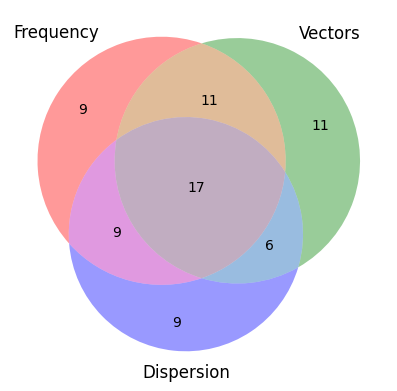

In [22]:
misclass_sets = []
with open("misclass_mod.json", "r") as f:  
    for line in f:
        misclass_sets.append(set(json.loads(line)))

import matplotlib.pyplot as plt
from matplotlib_venn import venn3

venn3(misclass_sets, ('Frequency', 'Vectors', 'Dispersion'))

plt.show()
# so 23 misclassified by one, 17 by two, 17 by all three, 63 by none


In [25]:
always_wrong = misclass_sets[0].intersection(misclass_sets[1]).intersection(misclass_sets[2])
print(len(always_wrong))
print(always_wrong)
print([(c, np.round(m, 2), np.round(h, 2), i>=60) for i, (c, m, h) in enumerate(target_compounds) if c in always_wrong])
always_correct = set([c[0] for c in target_compounds]).difference(*misclass_sets)
print(len(always_correct))
print(f"hardest compounds: {np.median([get_total_freq(compound) for compound in always_wrong])}, easiest compounds: {np.median([get_total_freq(compound) for compound in always_correct])}, \
      significance: {ttest_ind([get_total_freq(compound) for compound in always_wrong], [get_total_freq(compound) for compound in always_correct]).pvalue}")

17
{'day time', 'micrometer scale', 'sodium line', 'yolk formation', 'hydrogen scale', 'battery power', 'iron cylinder', 'incident light', 'winter temperature', 'quartz plate', 'iodine solution', 'glass case', 'millimetre scale', 'needle point', 'heating power', 'copper plate', 'zinc plate'}
[('incident light', 2.77, 3.62, False), ('sodium line', 4.2, 2.13, True), ('hydrogen scale', 4.21, 3.21, True), ('zinc plate', 4.29, 3.29, True), ('iodine solution', 4.31, 3.23, True), ('yolk formation', 4.31, 3.92, True), ('quartz plate', 4.33, 2.8, True), ('heating power', 4.36, 3.64, True), ('micrometer scale', 4.36, 3.93, True), ('winter temperature', 4.38, 3.85, True), ('needle point', 4.46, 3.15, True), ('copper plate', 4.53, 3.33, True), ('glass case', 4.54, 4.77, True), ('iron cylinder', 4.67, 3.73, True), ('millimetre scale', 4.71, 4.14, True), ('battery power', 4.73, 3.8, True), ('day time', 4.79, 4.0, True)]
48
hardest compounds: 125.0, easiest compounds: 182.5,       significance: 0.082

### Linear model to ascertain single feature weights

In [18]:
coefs = []
all_accuracies = []
for i in range(10):
    rep_accuracies = []
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED+i) #ensure different, but predictable random splits
    for train_ixs, test_ixs in kf.split(features, targets):
        train_features = [features[i] for i in train_ixs]
        train_targets = [targets[i] for i in train_ixs]
        test_features = [features[i] for i in test_ixs]
        test_targets = [targets[i] for i in test_ixs]
        linear = svm.SVC(kernel="linear", random_state=RANDOM_SEED)
        linear.fit(train_features, train_targets)
        preds = linear.predict(test_features)
        rep_accuracies.append(accuracy_score(test_targets, preds))
        coefs.append(linear.coef_[0])
    all_accuracies.append(rep_accuracies)

coef_avgs = [np.average([coefs[i][feat] for i in range(50)]) for feat in range(len(coefs[0]))]
print(list(zip(feature_names, coef_avgs)))

averages = [sum(accuracies)/len(accuracies) for accuracies in all_accuracies]
#print(f"Compositionality prediction on {corpus} with regards to the {constituent} using features {features_included}")
print(f"Final average accuracy: {np.round(np.average(averages), 3)} with standard deviation {np.round(np.std(averages), 3)}")


[('para_freq_bin1', 0.354437176255092), ('para_freq_bin2', 1.1892652636110796), ('para_freq_bin3', 0.1624127609574474), ('para_freq_bin4', 0.20382072840064536), ('para_freq_bin5', 1.3532941998780423), ('para_freq_bin6', 0.2544167493956312)]
Final average accuracy: 0.708 with standard deviation 0.007


In [19]:
low_comp_no_paras = sum([sum(feats) == 0 for feats in features[:60]])
high_comp_no_paras = sum([sum(feats) == 0 for feats in features[60:]])
print(f"On {constituent}: Of the low 60 {low_comp_no_paras} have no paraphrases, of the high 60 {high_comp_no_paras}")

On modifier: Of the low 60 13 have no paraphrases, of the high 60 4
